# Hybrid framework search algorithm

In [1]:
import os
import io
import random
import torch
import json
import pickle
import contextlib
import numpy as np
import matplotlib.pyplot as plt
from operator import itemgetter
from ultralytics import YOLO 
import torch.nn.functional as F
from tqdm import tqdm
from mylib import myutils
from mylib import simsettings
from mylib import simtools
from mylib import probtools
from mylib import dqn
from mylib import tensortools
from mylib import yolo_patch_softmax as _
from constants import OBS_SCALE, CELL_SIDE, MAP_RESOLUTION, DISPLAY_STEP
from constants import AGENT_HEIGHT, AGENT_RADIUS 
from constants import MAX_ITER_COEF, CONFIDENCE_THRESHOLD, LOCATION_ERROR_THRESHOLD, PSEUDO_COUNT_THRESHOLD
from constants import NUM_CLASSES, DIRICHLET_PRIOR
from constants import ACTIONS
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils

# Reload imported modules
%load_ext autoreload
%autoreload 2

# Load YOLO model
yolo_model = YOLO("yolo11x.pt")

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


In [2]:
# Load the JSON file for simulation
with open('simulation-data/simulations.json', 'r') as f:
    simulations = json.load(f)

# Select simulation 
simulation = simulations[9]
 
# Access its fields
SCENE = simulation["scene"]
TARGET_OBJECT = simulation["target_object"]
TARGET_OBJECT_ID = simulation["target_object_id"]
REAL_TARGET_LOCATION = simulation["target_object_location"]
INDEX = simulation["index"]

# Load the JSON file for RGB camera intrinsics
with open('simulation-data/camera-intrinsics.json', 'r') as f:
    intrinsics = json.load(f)

# Load bins per class
with open('simulation-data/object-classes-bins.json', 'r') as f:
    classes_bins = json.load(f)

# Load indoor objects
with open('simulation-data/indoor-objects.json', 'r') as f:
    data = json.load(f)
    indoor_objects = [list(item.values())[0] for item in data["indoor_classes"]]
    TARGET_OBJECT_CLASS_ID = indoor_objects.index(TARGET_OBJECT)

# Load Dirichlet priors
with open('simulation-data/dirichlet-alpha-priors-augmented.pkl', 'rb') as f:
    dirichlet_priors = pickle.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

Renderer: NVIDIA GeForce GTX 1060 6GB/PCIe/SSE2 

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[13:05:25:740614]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'ai2thor-hab' : Lighting Layout Attributes '/home/joaocbranco/projects/habitat-meta/ai2thor-hab/ai2thor-hab/configs/scenes/RoboTHOR/FloorPlan_Train5_1.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its binding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
[13:05:25:933735]:[Warning]:[Sim

by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 535.230.02
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits


orter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 3 pixels
Trade::BasisImporter::openData(): missing orientation metadata, assuming Y down. Set the assumeYUp option to suppress this warning.
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 2 pixels
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 3 pixels
Trade::BasisImporter::openData(): missing orientation metadata, assuming Y down. Set the assumeYUp option to suppress this warning.
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 2 pixels
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 3 pixels
Trade::BasisImporter::openData(): missing orientation metadata, assuming Y down. Set the assumeYUp option to suppres

In [3]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()

# Define navmesh settings
navmesh_settings = simsettings.create_navmesh_settings(AGENT_HEIGHT, AGENT_RADIUS, max_climb=0.2, max_slope=45.0, include_static_objects=True)

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the top-down map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=MAP_RESOLUTION, draw_border=True)
topdown_map, topdown_resolution = myutils.process_raw_topdown_map(topdown_map)

# Generate the coarse map --> 30 cm per pixel (robot has radius 15 cm)
grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=CELL_SIDE, draw_border=False)
grid_map, grid_resolution = myutils.process_raw_grid_map(grid_map, sim.pathfinder)

# Find free and occupied cells in the grid map
grid_free_cells, map_free_cells, world_free_coords = myutils.find_free_cells(grid_map, grid_resolution, topdown_map, topdown_resolution, sim.pathfinder)
grid_occ_cells, map_occ_cells, world_occ_coords = myutils.find_occupied_cells(grid_map, grid_resolution, topdown_map, topdown_resolution, sim.pathfinder)

# Merge free and occupied positions into a single list
grid_cells = grid_free_cells + grid_occ_cells
map_cells = map_free_cells + map_occ_cells
world_coords = world_free_coords + world_occ_coords

# Count the number of occupiable positions
num_free_cells = len(grid_free_cells)

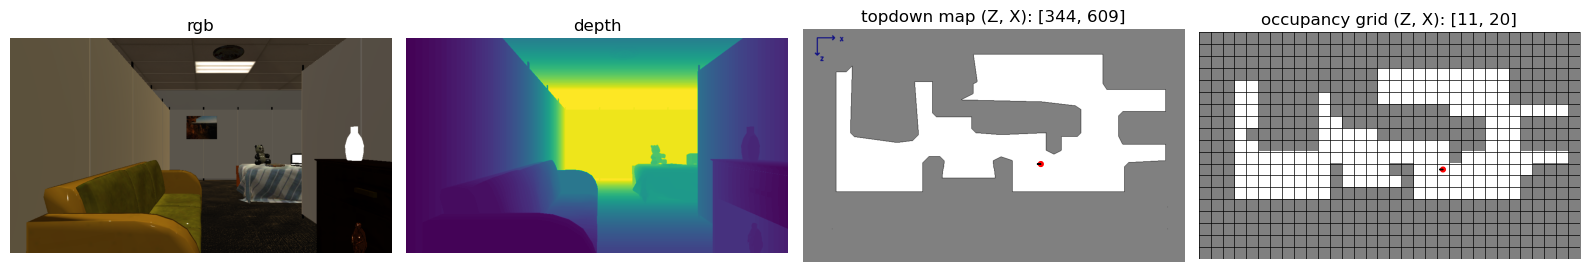

In [4]:
# Initialize belief map: NUM_CLASSES + 1 for the background 
belief_map = [[np.ones(NUM_CLASSES + 1) * DIRICHLET_PRIOR for _ in range(grid_resolution[1])] for _ in range(grid_resolution[0])]

# Initialize an agent
agent = sim.initialize_agent(sim_settings["default_agent"])

# Sample a random position (within the possible ones)
grid_position = random.choice(grid_free_cells)
idx = grid_free_cells.index(grid_position)
world_position = world_free_coords[idx]
map_position = map_free_cells[idx]

# Sample a random yaw rotation
agent_yaw = random.choice([0, 90, 180, 270])
agent_quart = myutils.yaw_to_quaternion(agent_yaw)

# Set agent state
agent_state = habitat_sim.AgentState()
agent_state.position = world_position
agent_state.rotation = agent_quart
agent.set_state(agent_state)

# Compute agent radius in both maps
min_bounds, max_bounds = sim.pathfinder.get_bounds()
x_dim = max_bounds[0] - min_bounds[0]
topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
grid_radius = (AGENT_RADIUS / x_dim * grid_resolution[0])

# Get initial agent position tuple and radius tuple
agent_radius = (topdown_radius, grid_radius)
agent_positions = (map_position, grid_position)

# Get initial observations and maps
observations = sim.get_sensor_observations(0)
rgb, depth = observations["color_sensor"], observations["depth_sensor"]

# Display the initial simulation state (maps + observations)
simtools.display_sim_state(rgb, depth, topdown_map, grid_map, agent_positions, agent_radius, agent_yaw)



Iteration: 12 | Action: move_forward | Epsilon: 0.100


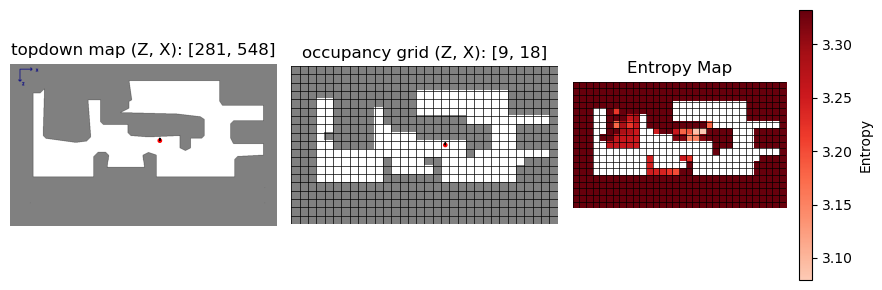



Iteration: 24 | Action: move_forward | Epsilon: 0.100


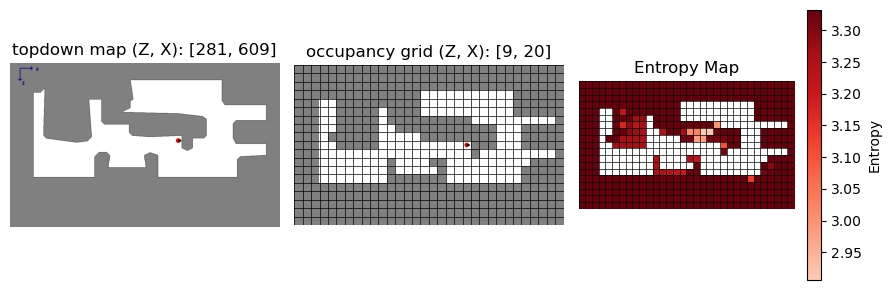



Iteration: 36 | Action: turn_right | Epsilon: 0.100


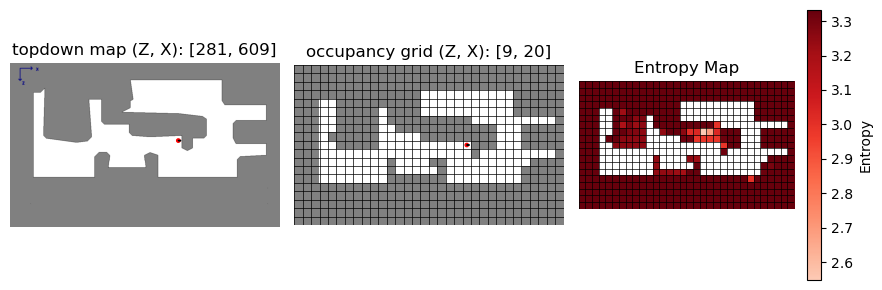



Iteration: 48 | Action: move_forward | Epsilon: 0.100


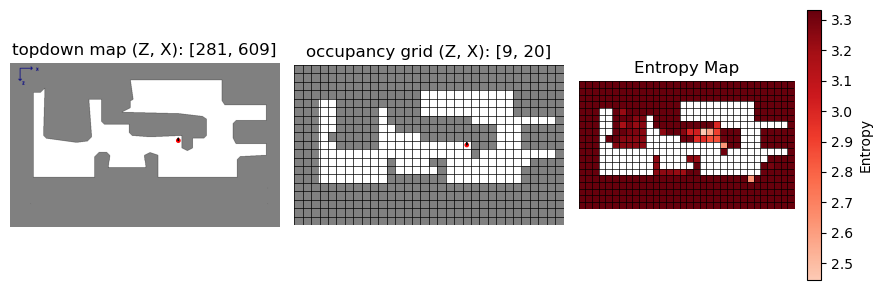



Iteration: 60 | Action: move_forward | Epsilon: 0.100


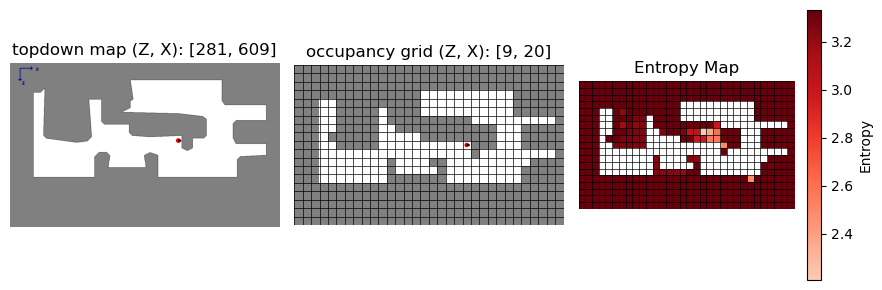



Iteration: 72 | Action: move_forward | Epsilon: 0.100


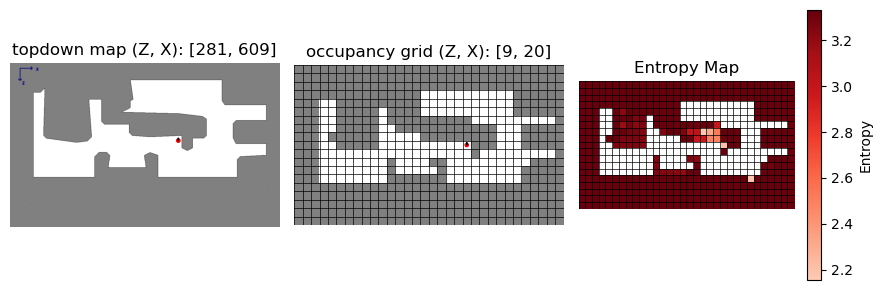



Iteration: 84 | Action: move_forward | Epsilon: 0.100


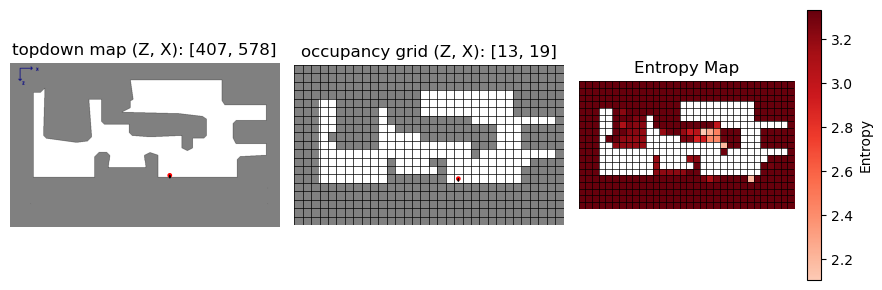



Iteration: 96 | Action: turn_right | Epsilon: 0.100


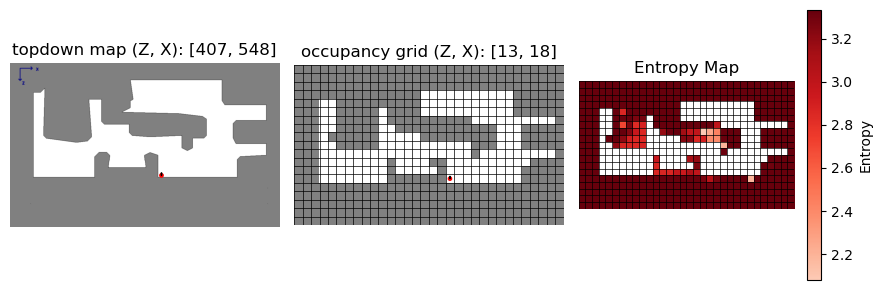



Iteration: 108 | Action: turn_right | Epsilon: 0.100


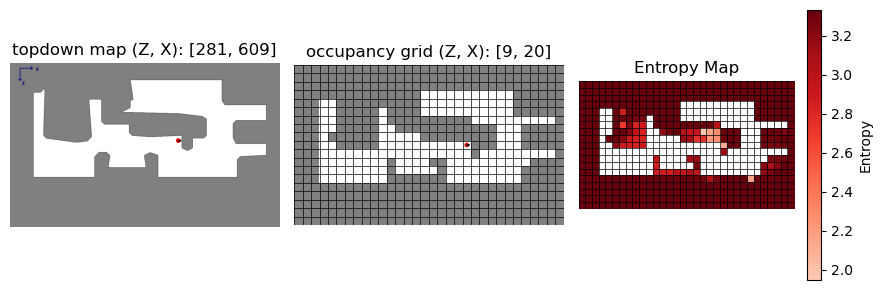



Iteration: 120 | Action: move_forward | Epsilon: 0.100


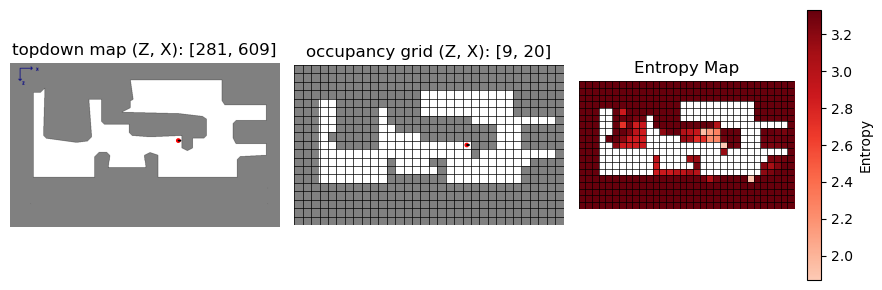

In [5]:
# Metrics init
target_found = False
num_actions = 0
travelled_distance = 0.0
location_error = float("inf")
episode_reward = 0.0

# Hyperparameters
load_pretrained = True  # Set to False to train from scratch
epsilon = 0.1  # Fixed epsilon for testing, can be adjusted

# Simulation parameters
NUM_ACTIONS = len(ACTIONS)  # Number of actions available
MAX_ITER = int(num_free_cells * MAX_ITER_COEF)  
DISPLAY_STEP = MAX_ITER // 10  

# DQN Network Parameters
PATCH_SIZE = 11  # Patch size for the DQN input

# Initialize DQN + target network
policy_net = dqn.ObjectSearchAgent(num_classes=NUM_CLASSES + 1, num_actions=NUM_ACTIONS, patch_size=PATCH_SIZE)
policy_net = policy_net.to(device)
if load_pretrained and os.path.exists("dqn_policy.pth"):
    policy_net.load_state_dict(torch.load("dqn_policy.pth"))
    policy_net.eval()  # Set policy network to evaluation mode

# LSTM vars
hidden_state = None

# Init current state tensors
pose = tensortools.init_pose_tensor(grid_position, grid_resolution, agent_yaw)
occ_patch = tensortools.init_occupancy_patch(grid_position, grid_resolution, grid_map, PATCH_SIZE)
belief_patch = tensortools.init_belief_patch(grid_position, grid_resolution, grid_map, belief_map, PATCH_SIZE, NUM_CLASSES + 1)
target_object_id = torch.tensor([TARGET_OBJECT_CLASS_ID], dtype=torch.long, device=device)  # Shape [1]

# Run episode
while not target_found and num_actions < MAX_ITER:

    # Select action using epsilon-greedy 
    action, hidden_state = dqn.select_action(policy_net, pose, occ_patch, belief_patch, target_object_id, NUM_ACTIONS, hidden_state, epsilon)
    action_str = list(ACTIONS)[action]  # Convert action index to action string

    # Perform action if valid
    if simtools.is_action_valid(action_str, grid_position, agent_yaw, grid_free_cells):
        grid_position, agent_yaw = simtools.perform_action(action_str, grid_position, agent_yaw)

    # Update agent position and state
    idx = grid_free_cells.index(grid_position)
    map_position, world_position = map_free_cells[idx], world_free_coords[idx]
    agent_positions = (map_position, grid_position)
    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

    # Update metrics
    num_actions += 1
    travelled_distance += simtools.compute_travelled_distance(agent_state.position, world_position)

    # Update agent state
    agent_state.position = world_position
    agent_state.rotation = agent_quart
    agent.set_state(agent_state)

    # Get observations
    obs = sim.get_sensor_observations(0)
    rgb, depth = obs["color_sensor"], obs["depth_sensor"]

    # YOLO Prediction
    results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
    detections = simtools.parse_yolo_detections(results)
    simtools.merge_rgb_yolo_outputs(rgb, detections)
    target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)
    
    # Initialize processed cells
    processed_cells = []

    # Process the observations
    for det in detections:
        box, class_id, confidence, name, prob_vector = itemgetter('box', 'class_id', 'confidence', 'name', 'prob_vector')(det)
        scale = myutils.compute_bbox_scale(box, rgb)

        # Center of bbox and depth value
        center_x, center_y = simtools.get_box_center(box)
        depth_value = depth[center_y, center_x]

        # Project to real world, grid and map coords
        camera_world_position = simtools.get_camera_pos_from_agent_pos(world_position, AGENT_HEIGHT)
        object_position = simtools.compute_real_world_position_from_pixel(camera_world_position, agent_quart, depth_value, center_x, center_y, intrinsics)
        object_map_position, object_grid_position = simtools.get_2d_coords(object_position, topdown_resolution, grid_resolution, sim.pathfinder)

        # Check if projected cell is outside free grid cells
        if object_grid_position in grid_free_cells:
            object_grid_position = simtools.get_closest_grey_cell(tuple(object_grid_position), grid_map)

        # Add this cell to processed cells
        if tuple(object_grid_position) not in processed_cells:
            processed_cells.append(tuple(object_grid_position))

        # Likelihood vector: likelihood of each class (Rule 1)
        likelihood_vector = probtools.compute_likelihood_vector(prob_vector, scale, dirichlet_priors, classes_bins)

        # Kaplan Update to the belief map in that cell
        grid_x, grid_y = object_grid_position
        belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

    # Compute every theoretically visible occupied cell
    rays = simtools.simulate_visibility_rays(grid_map, grid_position, agent_yaw)
    visible_occ_cells = simtools.compute_visible_occ_cells(rays, grid_map, depth, grid_cells, world_coords, grid_position, agent_state.rotation, intrinsics)
    
    # Go through every visible occupied cell and update the belief map
    for cell in visible_occ_cells:
        if tuple(cell) not in processed_cells:
            # Compute distance to the cell
            grid_x, grid_y = cell
            distance = np.linalg.norm((np.array(grid_position) - np.array([grid_x, grid_y]))* CELL_SIDE)

            # Compute the likelihood vector for the cell (Rule 2)
            likelihood_vector = probtools.compute_background_likelihood_vector(distance, NUM_CLASSES)

            # Kaplan update to the belief map in that cell
            belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

    # Check if the target object was found in the belief map
    if not target_found:
        target_found, target_grid_position = simtools.check_target_probability_in_entropy_map(belief_map, grid_cells, TARGET_OBJECT_CLASS_ID, PSEUDO_COUNT_THRESHOLD)

    # Compute next state
    next_pose = tensortools.init_pose_tensor(grid_position, grid_resolution, agent_yaw)
    next_occ_patch = tensortools.init_occupancy_patch(grid_position, grid_resolution, grid_map, PATCH_SIZE)
    next_belief_patch = tensortools.init_belief_patch(grid_position, grid_resolution, grid_map, belief_map, PATCH_SIZE, NUM_CLASSES + 1)
    next_target_object_id = target_object_id

    # Compute reward
    if target_found: # If the target object was found
        reward = 10.0
    elif torch.equal(next_pose, pose):  # If the agent did not move
        reward = -0.5
    else: # Step penalty
        reward = -0.01
    
    # Display the simulation state 
    if num_actions % DISPLAY_STEP == 0:
        print(f"\n\nIteration: {num_actions} | Action: {action_str} | Epsilon: {epsilon:.3f}")
        entropy_map = simtools.compute_entropy_map(belief_map, grid_map)
        simtools.display_topdown_and_entropy_maps_only(topdown_map, grid_map, entropy_map, agent_positions, agent_radius, agent_yaw)

    # Update variables
    pose = next_pose
    occ_patch = next_occ_patch
    belief_patch = next_belief_patch
    target_object_id = next_target_object_id 
    episode_reward += reward

In [6]:
# Compute the target location if it was found
if target_found:

    if target_grid_position is None: # Not found in the belief map
        # Real world position
        center_x, center_y = simtools.get_box_center(target_bbox)
        depth_value = depth[center_y, center_x]
        target_location = simtools.compute_real_world_position_from_pixel(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, intrinsics)
    else:
        # Real world position from grid position
        target_location = world_coords[grid_cells.index(target_grid_position)]

In [7]:
# Evaluating correctness of the target detection
if target_found:
    # Location error
    location_error = simtools.compute_location_error(target_location, REAL_TARGET_LOCATION)

    # Compare with threshold
    if location_error > LOCATION_ERROR_THRESHOLD:
        print(f"\nLocation error {location_error:.3f} m exceeds threshold {LOCATION_ERROR_THRESHOLD} m. FAILURE!")
        target_found = False

    # Plot maps with target
    target_positions = simtools.get_2d_coords(target_location, topdown_resolution, grid_resolution, sim.pathfinder)
    real_target_positions = simtools.get_2d_coords(REAL_TARGET_LOCATION, topdown_resolution, grid_resolution, sim.pathfinder)
    simtools.display_sim_observations(rgb, depth)
    simtools.display_topdown_maps_with_target(topdown_map, grid_map, agent_positions, agent_radius, agent_yaw, target_positions, real_target_positions)

# Display simulation result and metrics
if target_found:
    print(f"\nTarget object <{TARGET_OBJECT}> found after {num_actions} actions!")
    print(f"Found location: {target_location}")
else:
    print(f"\nTarget object <{TARGET_OBJECT}> not found after {num_actions} actions!")

print(f"Ground-truth location: {REAL_TARGET_LOCATION}")
print(f"Number of actions: {num_actions}")
print(f"Travelled distance: {travelled_distance:.2f} m")
print(f"Computed location error: {location_error:.3f} m")


Target object <teddy bear> not found after 127 actions!
Ground-truth location: [-8.680521965026855, 0.5778275728225708, -3.2672173976898193]
Number of actions: 127
Travelled distance: 6.20 m
Computed location error: inf m


In [8]:
sim.close()  # Close the simulator